In [1]:
# Adjust the working directly to import packages using the root package
import sys
import os
notebook_dir = os.getcwd()
print(notebook_dir)
parent_dir = os.path.dirname(notebook_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks/slt-examples


In [2]:
# import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns
# import numpy as np
import pandas as pd

from sklearn_ext.mixture import BinomialMixture
# from sklearn.utils import resample

# from IPython.display import display, clear_output
from tqdm.notebook import tqdm

# from joblib import Parallel, delayed
# import multiprocessing as mp
# from plot import visualize_joint_confidence_regions
# import seaborn as sns
from matplotlib.lines import Line2D
# import random

default_palette = 'tab10'
# Enable LaTeX rendering
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


In [3]:
dgps_filepath = "./binomix/meta.csv"
dgps=pd.read_csv(dgps_filepath, index_col=0).reset_index()
datasets = dgps["dsid"].unique()
print(dgps)

   dsid  n_trials  rho1   p1   p2  obs_count  rho2
0     0       100   0.7  0.3  0.2       1000   0.3
1     1       100   0.7  0.3  0.3       1000   0.3
2     2       100   1.0  0.3  0.2       1000   0.0


In [4]:
obs_df=pd.read_csv("./binomix/obs.csv", index_col=0).reset_index()
obs_count = len(obs_df)
ss_steps = [np.ceil(x).astype(int) for x in [obs_count*.1, obs_count*.5, obs_count]]
print(obs_df.head())
print(f"using sample counts {ss_steps}")

   index  n_trials  x_0  x_1  x_2
0      0       100   24   33   32
1      1       100   19   41   24
2      2       100   27   25   33
3      3       100   17   27   26
4      4       100   23   26   27
using sample counts [np.int64(100), np.int64(500), np.int64(1000)]


In [5]:
n_replications = 1000 # to visualize the true mle sampling distribution, let's generate K trials

# we will save the results so we don't have to spend a lot of time on this
repls_pathstr = "./binomix/ds{dsid}_ss{ss}_repls.csv"

for dsid in datasets:
    for ss in ss_steps:
        repls_file = Path(repls_pathstr.format(dsid=dsid, ss=ss))
        if repls_file.exists(): # check if this data has already been generated
            print(f"File {repls_file} exists, skipping trials creation!.")
        else:
            if repls_file.parent: # create parents dir if not already
                repls_file.parent.mkdir(parents=True, exist_ok=True)
        
            repls = {}
    
            dgp = dgps.query(f"dsid=={dsid}")
            n_trials = dgp["n_trials"].unique().item()
            weights = dgp[["rho1", "rho2"]].iloc[0].tolist()
            probs = dgp[["p1", "p2"]].iloc[0].tolist()
            dd = BinomialMixture(n_components=2, weights_init=weights, probs_init=probs, n_trials=n_trials)
    
            repls["n_trials"] = np.ones(ss, dtype=int)*n_trials
            for k in tqdm(range(0, n_replications), desc=f"dataset {dsid} replications"):
                samples = dd.sample(n_samples=ss)
                repls[f"x_{k}"] = samples[0].astype(int).tolist()
    
            repls_df = pd.DataFrame(repls)
            repls_df.to_csv(repls_file)
            
            print(f"Created {repls_file} with {n_replications} for {len(datasets)} data sets!.")

dataset 0 replications:   0%|          | 0/1000 [00:00<?, ?it/s]

Created binomix/ds0_ss100_repls.csv with 1000 for 3 data sets!.


dataset 0 replications:   0%|          | 0/1000 [00:00<?, ?it/s]

Created binomix/ds0_ss500_repls.csv with 1000 for 3 data sets!.


dataset 0 replications:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Created binomix/ds2_ss100_repls.csv with 1000 for 3 data sets!.


dataset 2 replications:   0%|          | 0/1000 [00:00<?, ?it/s]

Created binomix/ds2_ss500_repls.csv with 1000 for 3 data sets!.


dataset 2 replications:   0%|          | 0/1000 [00:00<?, ?it/s]

Created binomix/ds2_ss1000_repls.csv with 1000 for 3 data sets!.


In [6]:
# compute the mle fit for each trial to be plotted to study the true MLE distribution
def compute_mle(x_obs, max_iter=10**6, tol=10e-4):
    # Fit main GMM
    bmm = BinomialMixture(n_components=2,
                          max_iter=max_iter, 
                          tol=tol,
                          n_init=10)

    bmm.fit(x_obs)
    bmm._enforce_ordering() 

    mle = {
        "p1": bmm.probs_[0],
        "p2": bmm.probs_[1], 
        "rho1": bmm.weights_[0],
        "rho2": bmm.weights_[1]
    }
    return mle, bmm


# we will save the results so we don't have to spend a lot of time on this
repls_mle_file = Path("./binomix/repls_mle.csv")
if repls_mle_file.exists(): # check if this data has already been generated
    print(f"File {repls_mle_file} exists, skipping trials mle estimates!.")
else:
    if repls_mle_file.parent: # create parents dir if not already
        repls_mle_file.parent.mkdir(parents=True, exist_ok=True)

    repls_mle={"repl": [], "rho1": [], "rho2":[], "p1":[], "p2":[], "dsid": [], "ss": [], "n_trials": []}
    for dsid in datasets:
        for ss in ss_steps:
            repls = pd.read_csv(repls_pathstr.format(dsid=dsid, ss=ss))
            for k in tqdm(range(0, n_replications), desc=f"mle fit for dataset {dsid}, ss={ss}"):
                X = repls[[f"x_{k}", "n_trials" ]]
                estimate, _ = compute_mle(x_obs=X)
                assert estimate["p1"] >= estimate["p2"], f"p1={estimate["p1"]} < p2={estimate["p2"]}"
                repls_mle["repl"].append(k)
                repls_mle["rho1"].append(estimate["rho1"])
                repls_mle["rho2"].append(estimate["rho2"])
                repls_mle["p1"].append(estimate["p1"])
                repls_mle["p2"].append(estimate["p2"])
                repls_mle["dsid"].append(dsid)
                repls_mle["ss"].append(ss)
                repls_mle["n_trials"].append(X["n_trials"].unique().item())
    
    pd.DataFrame(repls_mle).to_csv(repls_mle_file)
    print(f"File {repls_mle_file} created!")

repls_mle_df = pd.read_csv(repls_mle_file)
repls_mle_df.head()
repls_mle_df

mle fit for dataset 0, ss=100:   0%|          | 0/1000 [00:00<?, ?it/s]

mle fit for dataset 0, ss=500:   0%|          | 0/1000 [00:00<?, ?it/s]

mle fit for dataset 0, ss=1000:   0%|          | 0/1000 [00:00<?, ?it/s]

mle fit for dataset 1, ss=100:   0%|          | 0/1000 [00:00<?, ?it/s]

mle fit for dataset 1, ss=500:   0%|          | 0/1000 [00:00<?, ?it/s]

...

mle fit for dataset 2, ss=100:   0%|          | 0/1000 [00:00<?, ?it/s]

mle fit for dataset 2, ss=500:   0%|          | 0/1000 [00:00<?, ?it/s]

mle fit for dataset 2, ss=1000:   0%|          | 0/1000 [00:00<?, ?it/s]

File binomix/repls_mle.csv created!


,Unnamed: 0,repl,rho1,rho2,p1,p2,dsid,ss,n_trials
0,0,0,5.779361e-01,0.422064,0.303079,0.196510,0,100,100
1,1,1,5.681589e-01,0.431841,0.310675,0.203749,0,100,100
2,2,2,6.745215e-01,0.325479,0.292249,0.195625,0,100,100
3,3,3,6.437103e-01,0.356290,0.300672,0.214305,0,100,100
4,4,4,6.465124e-01,0.353488,0.317651,0.213117,0,100,100
...,...,...,...,...,...,...,...,...,...
8995,8995,995,5.959887e-01,0.404011,0.309943,0.285209,2,1000,100
8996,8996,996,2.651878e-14,1.000000,0.396115,0.300260,2,1000,100
8997,8997,997,5.641811e-03,0.994358,0.419531,0.300016,2,1000,100
8998,8998,998,2.123922e-13,1.000000,0.394368,0.299880,2,1000,100


In [9]:
# fitting observations themselves
mle_est_file = Path("./binomix/mle_est.csv")
if mle_est_file.exists(): # check if this data has already been generated
    print(f"File {mle_est_file} exists, skipping mle estimation.")
else:
    if mle_est_file.parent: # create parents dir if not already
        mle_est_file.parent.mkdir(parents=True, exist_ok=True)
    mle_est={"rho1": [], "rho2":[], "p1":[], "p2":[], "dsid": [], "ss": []}
    for dsid in datasets:
        for ss in ss_steps:
            X = obs_df[[f"x_{dsid}", "n_trials"]]
            estimate, _=compute_mle(x_obs=X[0:ss])
            assert estimate["p1"] >= estimate["p2"], f"p1={estimate["p1"]} < p2={estimate["p2"]}"
            mle_est["rho1"].append(estimate["rho1"])
            mle_est["rho2"].append(estimate["rho2"])
            mle_est["p1"].append(estimate["p1"])
            mle_est["p2"].append(estimate["p2"])
            mle_est["dsid"].append(dsid)
            mle_est["ss"].append(ss)

    pd.DataFrame(mle_est).to_csv(mle_est_file)

mle_es_df=pd.read_csv(mle_est_file)
mle_es_df

File binomix/mle_est.csv exists, skipping mle estimation.


,Unnamed: 0,rho1,rho2,p1,p2,dsid,ss
0,0,5.262474e-01,0.473753,0.302435,0.206742,0,100
1,1,6.726149e-01,0.327385,0.300570,0.201697,0,500
2,2,6.506987e-01,0.349301,0.304155,0.205659,0,1000
3,3,8.310193e-02,0.916898,0.363346,0.294150,1,100
4,4,1.956117e-03,0.998044,0.438351,0.302314,1,500
5,5,1.083730e-03,0.998916,0.473399,0.301143,1,1000
6,6,7.327987e-01,0.267201,0.311067,0.265158,2,100
7,7,1.105503e-17,1.000000,0.432144,0.300220,2,500
8,8,5.595032e-18,1.000000,0.424455,0.298160,2,1000


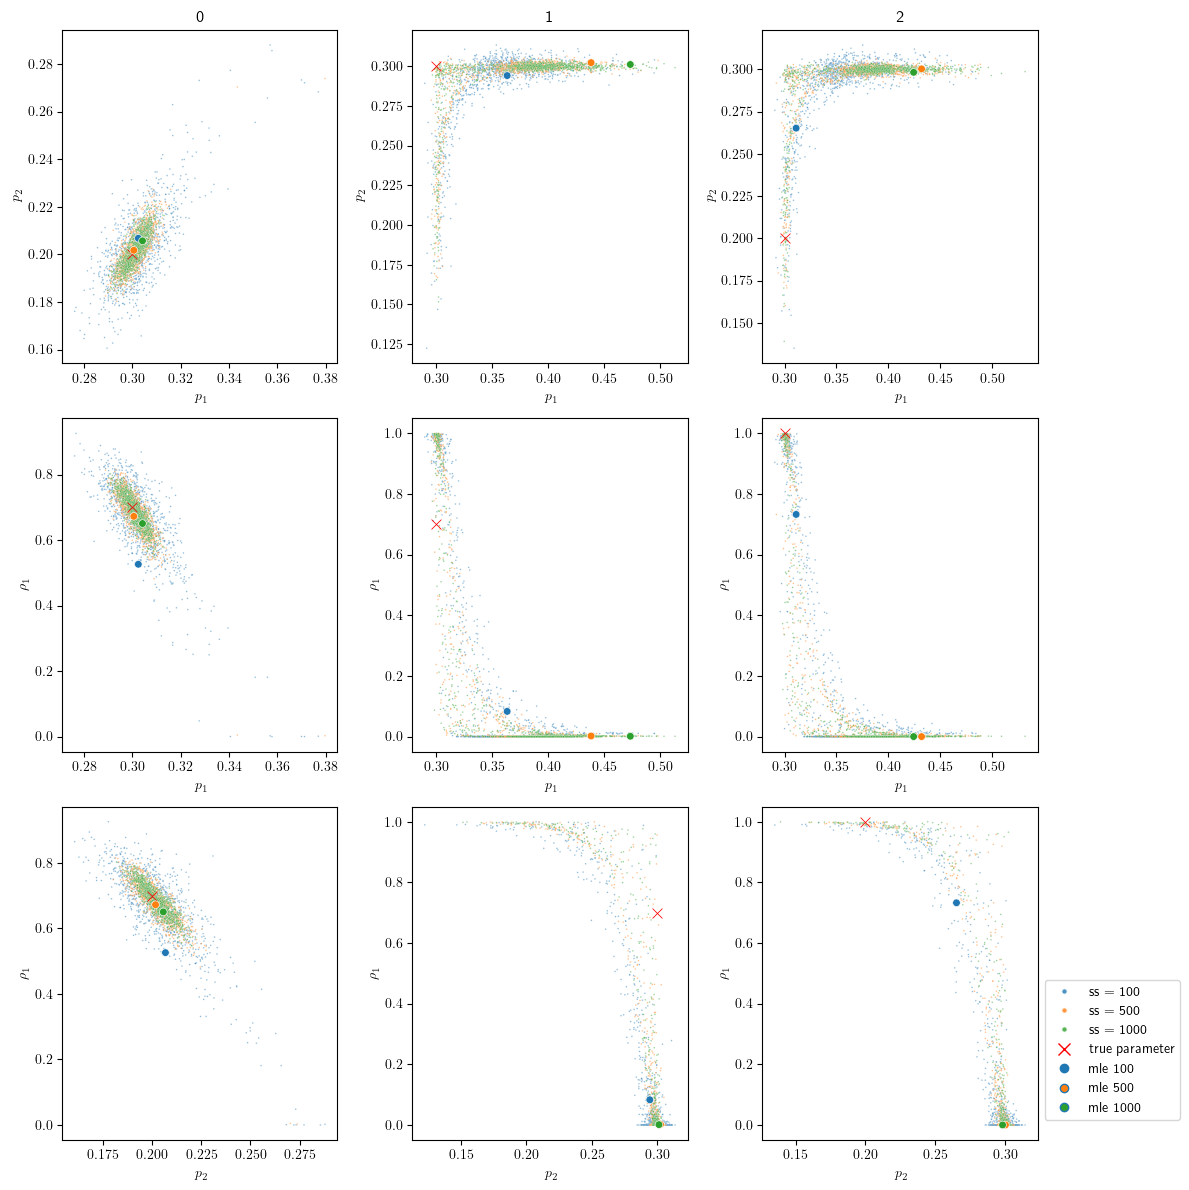

In [21]:
def plot_mle(ddf, dgps):
    datasets = ddf["dsid"].unique()
    fig, axes = plt.subplots(
        3, len(datasets), 
        figsize=(4*len(datasets), 12),
        sharex=False,
        sharey=False
    )
    
    pairs = [('p1', 'p2'), ('p1', 'rho1'), ('p2', 'rho1'), ]
    pair_labels = [('$p_1$', '$p_2$'), ('$p_1$', '$\\rho_1$'), ('$p_2$', '$\\rho_1$'), ]
    dsids = sorted(ddf['dsid'].unique())
    
    for i, ((x_var, y_var), (x_label, y_label)) in enumerate(zip(pairs, pair_labels)):
        for j, dsid in enumerate(dsids):
            data_subset = ddf[ddf['dsid'] == dsid]
            
            # Use seaborn scatterplot instead of matplotlib scatter
            sns.scatterplot(data=data_subset, x=x_var, y=y_var, hue="ss",
                           alpha=0.5, s=5, marker='.', ax=axes[i, j], legend=False, palette=default_palette)
    
            # overlay the true parameter
            sns.scatterplot(data=dgps[dgps["dsid"]==dsid], x=x_var, y=y_var, 
                           color='red', marker='x', s=50, alpha=1.0, ax=axes[i, j], legend=False)
                
            # overlay the mle estimates
            mles = mle_es_df.query(f"dsid=={dsid}")
            sns.scatterplot(data=mles, x=x_var, y=y_var, hue="ss",
                           marker='o', s=30, alpha=1, ax=axes[i, j], legend=False, palette=default_palette)
            
            axes[i, j].set_xlabel(x_label)
            axes[i, j].set_ylabel(y_label)
            
            if i == 0:
                axes[i, j].set_title(f'{dsid}')
    
    # Create legend elements
    legend_elements = []
    colors = sns.color_palette(n_colors=len(ss_steps))
    # Add hue legend (for different 'n' values)
    for idx, ss in enumerate(ss_steps):
        legend_elements.append(Line2D([0], [0], marker='.', color='w', 
                                     markerfacecolor=colors[idx], markersize=8, 
                                     label=f'ss = {ss}', alpha=0.8))
    
    # overlay true parameters
    legend_elements.append(Line2D([0], [0], marker='x', color='red', 
                                 linestyle='None', markersize=8, 
                                 label='true parameter'))

    # overlay mle estimates from obseration
    for idx, ss in enumerate(ss_steps):
        legend_elements.append(Line2D([0], [0], marker='o',
                                     linestyle='None', markersize=6, 
                                      markerfacecolor=colors[idx],
                                     label=f'mle {ss}'))
    
    # Add legend to the figure
    plt.legend(handles=legend_elements, loc='best', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.savefig('binomix/mle_scatter_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_mle(ddf=repls_mle_df, dgps=dgps)

In [35]:
import random
# compute the confidence region using gaussian approximation
estimates={"dsid": [], "n": [], "rho1": [], "rho2":[], "p1":[], "p2":[], "confidence_regions": []}
for dsid in range(datasets_count):
    for n in tqdm(n_steps, desc=f"n_steps"):
        file = Path(obs_pathstr.format(dsid=dsid, n=n))
        Xs = pd.read_csv(file)
        estimate, model =compute_mle(x_obs=Xs[[f"x_{repl_index}", "n_trials", ]])
        estimates["dsid"].append(dsid)
        estimates["n"].append(n)
        estimates["rho1"].append(estimate["rho1"])
        estimates["rho2"].append(estimate["rho2"])
        estimates["p1"].append(estimate["p1"])
        estimates["p2"].append(estimate["p2"])
        confidence_region_data = model.compute_fisher_confidence_region(Xs[[f"x_{repl_index}", "n_trials", ]])
        estimates["cov_matrix"].append(confidence_region_data["cov_matrix"])
        estimates["chi2_critical"].append(confidence_region_data["chi2_critical"])
        estimates["confidence_level"].append(confidence_region_data["confidence_level"])
        estimates["standard_errors"].append(confidence_region_data["standard_errors"])

estimates

n_steps:   0%|          | 0/3 [00:00<?, ?it/s]

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have your mle_df dataframe
g = sns.pairplot(
    mle_df[["n", "rho1", "p1", "p2"]].rename(columns={
        'n': 'n',
        'rho1': '$\\rho_1$', 
        'p1': '$p_1$', 
        'p2': '$p_2$'
    }), 
    hue='n',
    hue_order=[1000, 500, 100],  # explicit order
    height=4,
    aspect=1,
    diag_kind="hist",
    plot_kws={
        'alpha': 0.5,
        's': 5,
        'marker': '.',
        'linewidth': 0,  # removes edge lines for cleaner look
    },
    diag_kws={
        'alpha': 0.7,
        'bins': 30,  # if using histograms on diagonal
    }
)

# Set axis labels with LaTeX formatting
# g.set_axis_labels('$p_1$', '$\\rho_1$')

plt.show()

KeyError: "['n'] not in index"

In [ ]:
def resample_and_fit(X, random_state, n_samples, max_iter=10**3, tol=10**3, n_init=1):
    try:
        X_boot = resample(X, random_state=random_state, n_samples=n_samples)
        bmm_boot = BinomialMixture(n_components=2, 
                                   tol=tol, 
                                   max_iter=max_iter,
                                   n_init=n_init)
        
        bmm_boot.fit(X_boot)
        
        if not bmm_boot.converged_:
            raise Error(f"Iteration {i} didn't converge!")

        bmm_boot._enforce_ordering() 
    
        mle = {
            "p1": bmm_boot.probs_[0],
            "p2": bmm_boot.probs_[1], 
            "rho1": bmm_boot.weights_[0],
            "rho2": bmm_boot.weights_[1],
            'iteration': i
        }

    except Exception as e:
        print(f"Error in bootstrap iteration {i}: {e}")
        return None

In [32]:
##### Set the known variances
n_incr = int(n_samples*1/5)
#partition the total samples into 1/10 increments to show case the impact of number of trials on estimates
n_steps = np.arange(n_incr, n_samples+n_incr, n_incr)
estimates_ts = {}

for e in tqdm(range(total_experiments), desc=f"experiment "):
    w0 = dgp_df.loc[f"{e}"]
    x_obs=(data[[f'{e}_x', f"{e}_n"]]).values
    for i in tqdm(range(len(n_steps)), desc=f"trials "):
        nn = n_steps[i]
        estimates = compute_mle(x_obs=x_obs[:nn],
                                n_bootstrap=10000,
                                max_iter=10**3,
                                tol=10e-3)

        if f"dataset_{e}" not in estimates_ts:
            estimates_ts[f"dataset_{e}"] = { "n":[], "p1": [], "p2": [], "rho1": [], "rho2": []}

        ds = estimates_ts.get(f"dataset_{e}")
        ds["n"].append(nn)
        for pname in ["p1", "p2", "rho1", "rho2"]:
            ss = estimates[pname]["bootstraps"]
            ci_upper = estimates[pname]["ci_upper"]
            ci_lower = estimates[pname]["ci_lower"]
            
            ds[pname].append({
                "mle": estimates[pname]["mle"],
                "bootstraps": estimates[pname]["bootstraps"],
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "boot_min": np.min(estimates[pname]["bootstraps"]),
                "boot_max": np.max(estimates[pname]["bootstraps"])
            })

experiment :   0%|          | 0/4 [00:00<?, ?it/s]

trials :   0%|          | 0/5 [00:00<?, ?it/s]

trials :   0%|          | 0/5 [00:00<?, ?it/s]

trials :   0%|          | 0/5 [00:00<?, ?it/s]

trials :   0%|          | 0/5 [00:00<?, ?it/s]

Text(0.5, 0.98, 'Bootstrap confidence regions, n=250')

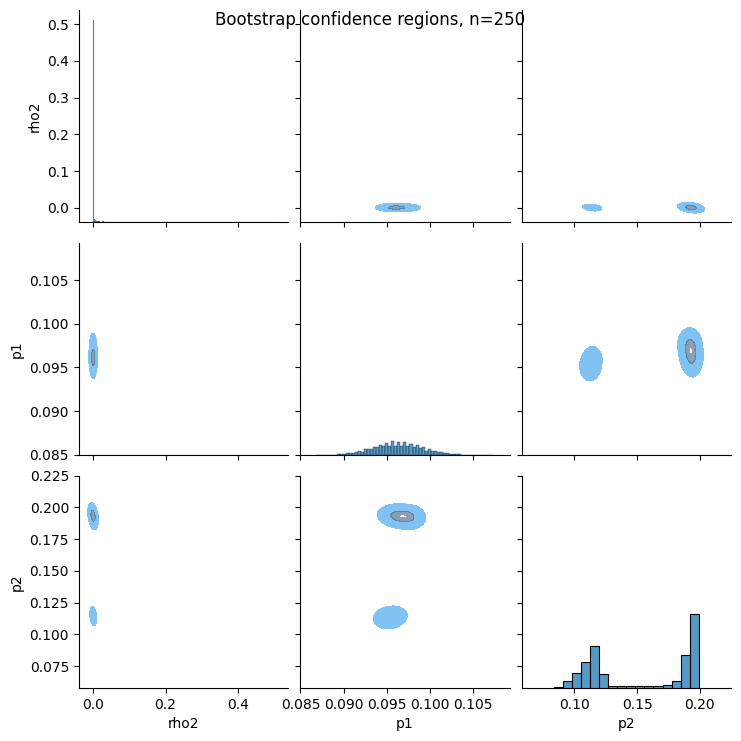

In [37]:
# Create DataFrame
dsid = f"dataset_2"
w_true = {
    # "rho1": dgp_df.loc["1", ["rho1"]],
    "rho2": dgp_df.loc["1", ["rho2"]],
    "p1": dgp_df.loc["1", ["p1"]],
    "p2": dgp_df.loc["1", ["p2"]]
}

# for i in range(len(estimates_ts[dsid]["rho1"])):
crdata = pd.DataFrame({
    # 'rho1': estimates_ts[dsid]["rho1"][4]["bootstraps"],
    'rho2': estimates_ts[dsid]["rho2"][1]["bootstraps"], 
    'p1': estimates_ts[dsid]["p1"][1]["bootstraps"],
    'p2': estimates_ts[dsid]["p2"][1]["bootstraps"]
})

# fig, axes = visualize_joint_confidence_regions(crdata, 
#                                           true_params=w_true,
#                                           methods=['kde', 'ellipse']
#                                               )  # Focus on key methods
    
# Create pairplot
g = sns.pairplot(crdata,
                 # corner=True,
                 kind="kde",
                 diag_kind='hist',
                 plot_kws={'levels': [0.68, 0.95, 0.995], 
                           'alpha': 0.6,
                           'fill': True} # Filled contours
                )

# g.set(xlim=(0, 1), ylim=(0, 1))
# Customize the plot
g.fig.suptitle(f'Bootstrap confidence regions, n={estimates_ts[dsid]["n"][i]}')
    
    # print(estimates_ts[dsid]["rho2"][1]["ci_lower"])
    # print(estimates_ts[dsid]["rho2"][1]["ci_upper"])

In [31]:
# Plot the results
def plot_percentile_results(data, pname):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    global_min = None
    global_max = None
    for i, dataset in enumerate([f'dataset_{j}' for j in range(0, total_experiments)]):
        ax = axes[i]

        mle = [x["mle"] for x in data[dataset][pname]]
        ci_lower = [x["ci_lower"] for x in data[dataset][pname]]
        ci_upper = [x["ci_upper"] for x in data[dataset][pname]]

        if not global_min:
            global_min = np.min(ci_lower)
        else:
            possible_min = np.min(ci_lower)
            global_min = global_min if global_min < possible_min else possible_min
            
        if not global_max:
            global_max = np.max(ci_upper)
        else:
            possible_max = np.max(ci_upper)
            global_max = global_max if global_max > possible_max else possible_max
        
        x = data[dataset]['n']
        y = mle
        ci_lower = ci_lower
        ci_upper = ci_upper
        
        # Plot estimate
        ax.plot(x, y, 'o-', color='gray', markersize=4)
        
        # Plot confidence interval
        ax.fill_between(x, ci_lower, ci_upper, alpha=0.3, color='pink')
        truth = (dgp_df.loc[f"{i}", [pname]]).item()
        # print(f"dataset={dataset}, truth={truth:0.3f}, mle={data[dataset]['mle'][pname]}")
        ax.axhline(y=truth, color='blue', linestyle='-', linewidth=2, alpha=0.8)
        ax.set_title(f'Dataset {i+1} - 95th Percentile')
        ax.set_xlabel('Sample Size')
        ax.set_ylabel(f'{pname} estimate')
        ax.grid(True, alpha=0.3)

    padding = (global_max-global_min)*0.1
    for ax in axes:
        ax.set_ylim(global_min-padding, global_max+padding)
    
    plt.tight_layout()
    plt.show()

In [ ]:
plot_percentile_results(data=estimates_ts, pname="p1")

In [ ]:
plot_percentile_results(estimates_ts, pname="p2")

In [ ]:
plot_percentile_results(estimates_ts, pname="rho2")